# FASE 3 — Entrenamiento

Entrenamos `DermaCNN` con:
- `CrossEntropyLoss` ponderada por clase (desbalance)
- Optimizador `AdamW` + scheduler `CosineAnnealingLR`
- Early stopping para evitar sobreajuste
- Checkpointing del mejor modelo (por F1-Macro en validación)
- Curvas de pérdida y métricas en tiempo real

## 1. Imports y configuración

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time, os
from tqdm import tqdm
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, confusion_matrix

# Módulos de fases anteriores
from pipeline import get_dataloaders, CLASS_NAMES, CLASS_WEIGHTS, NUM_CLASSES
from model import DermaCNN

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB


## 2. Hiperparámetros

## 3. DataLoaders, Modelo, Loss, Optimizador

In [2]:
# fase3_config_v13.py
# v13 = fusiones CORRECTAS del taller + skip connections + pesos v10
#
# CAMBIO PRINCIPAL: model.py v3 con las dos fusiones corregidas:
#   Bloque 3: GaussianSimilarityFusion  exp(-(X1-X2)²/2) ⊙ (X1+X2)
#   Bloque 4: BilateralAttentionFusion  σ(X1)⊙X2 + σ(X2)⊙X1
#
# Todo lo demás igual a v10 (el mejor resultado histórico F1=0.5808):
#   pesos [1.20,1.40,1.00,2.00,1.10,0.48,0.89], OneCycleLR, mixup=0.2
#
# INSTRUCCIÓN: reemplaza model.py Y pipeline.py, reiniciar kernel.

from pipeline import get_dataloaders, CLASS_NAMES, CLASS_WEIGHTS, NUM_CLASSES
from model import DermaCNN
import torch
import torch.nn as nn
import numpy as np
import time
from tqdm import tqdm
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

CONFIG = {
    'batch_size'   : 64,
    'num_epochs'   : 120,
    'lr'           : 1e-3,
    'weight_decay' : 1e-5,
    'dropout'      : 0.25,
    'patience'     : 25,
    'min_delta'    : 1e-4,
    'checkpoint'   : 'best_model_v13.pth',
    'num_workers'  : 0,
    'mixup_alpha'  : 0.2,
    'pct_start'    : 0.20,
}

train_loader, val_loader, test_loader = get_dataloaders(num_workers=CONFIG['num_workers'])

imgs, _ = next(iter(train_loader))
assert imgs.shape[-1] == 64
print(f'✅ Imágenes: {imgs.shape}')

model = DermaCNN(num_classes=NUM_CLASSES, dropout=CONFIG['dropout']).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Parámetros: {total_params:,}')
assert total_params > 495032, '❌ Verificar model.py con skip connections'

class_weights_tensor = torch.FloatTensor(CLASS_WEIGHTS).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.05)

optimizer = torch.optim.AdamW(model.parameters(),
                               lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=CONFIG['lr'],
    steps_per_epoch=len(train_loader),
    epochs=CONFIG['num_epochs'],
    pct_start=CONFIG['pct_start'],
    anneal_strategy='cos',
)

print(f'Device     : {DEVICE}')
print(f'Parámetros : {total_params:,}')
print(f'Checkpoint : {CONFIG["checkpoint"]}')
print(f'Épocas     : {CONFIG["num_epochs"]} (patience={CONFIG["patience"]})')
print()
print('v13 — cambios respecto a v10:')
print('  Bloque 3: GaussianSimilarityFusion  exp(-(X1-X2)²/2) ⊙ (X1+X2)')
print('  Bloque 4: BilateralAttentionFusion  σ(X1)⊙X2 + σ(X2)⊙X1')
print('  Pesos: [1.20,1.40,1.00,2.00,1.10,0.48,0.89] (igual a v10)')
print('  Todo lo demás: idéntico a v10')
print()

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            probs  = torch.softmax(logits, dim=1)
            all_preds.extend(probs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    ap = np.array(all_preds); al = np.array(all_labels); apr = np.array(all_probs)
    return (total_loss/len(loader.dataset),
            accuracy_score(al, ap),
            f1_score(al, ap, average='macro', zero_division=0),
            roc_auc_score(al, apr, multi_class='ovr', average='macro'),
            ap, al, apr)

class EarlyStopping:
    def __init__(self, patience=25, min_delta=1e-4, path='best.pth'):
        self.patience=patience; self.min_delta=min_delta; self.path=path
        self.counter=0; self.best_score=None; self.stop=False
    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score=score; self._save(model, score)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            print(f'     EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience: self.stop = True
        else:
            self._save(model, score); self.best_score=score; self.counter=0
    def _save(self, model, score):
        torch.save(model.state_dict(), self.path)
        print(f'     ✅ Checkpoint guardado (F1={score:.4f})')

early_stopping = EarlyStopping(patience=CONFIG['patience'],
                                min_delta=CONFIG['min_delta'],
                                path=CONFIG['checkpoint'])

print('Iniciando entrenamiento v13...')
print('='*70)
start_time = time.time()

for epoch in range(1, CONFIG['num_epochs'] + 1):
    model.train()
    train_loss, train_preds, train_labels_ep = 0.0, [], []
    pbar = tqdm(train_loader, desc=f'Epoch {epoch:03d}/{CONFIG["num_epochs"]}',
                leave=False, ncols=80)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        imgs_mix, y_a, y_b, lam = mixup_data(imgs, labels, CONFIG['mixup_alpha'])
        optimizer.zero_grad()
        logits = model(imgs_mix)
        loss   = mixup_criterion(criterion, logits, y_a, y_b, lam)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item() * imgs.size(0)
        train_preds.extend(logits.argmax(dim=1).cpu().numpy())
        train_labels_ep.extend(labels.cpu().numpy())
        pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    t_loss = train_loss/len(train_loader.dataset)
    t_acc  = accuracy_score(train_labels_ep, train_preds)
    t_f1   = f1_score(train_labels_ep, train_preds, average='macro', zero_division=0)
    v_loss, v_acc, v_f1, v_auc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    current_lr = optimizer.param_groups[0]['lr']
    elapsed = (time.time() - start_time) / 60

    print(f'Ep {epoch:03d} | TLoss={t_loss:.4f} Tacc={t_acc:.3f} TF1={t_f1:.3f} | '
          f'VLoss={v_loss:.4f} Vacc={v_acc:.3f} VF1={v_f1:.3f} VAUC={v_auc:.3f} | '
          f'LR={current_lr:.2e} | {elapsed:.1f}min')

    early_stopping(v_f1, model)
    if early_stopping.stop:
        print(f'\n⛔ Early stopping en época {epoch}')
        break

total_time = (time.time() - start_time) / 60
print('='*70)
print(f'Entrenamiento finalizado en {total_time:.1f} min')
print(f'Mejor F1-Macro en validación: {early_stopping.best_score:.4f}')

Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
✅ Imágenes: torch.Size([64, 3, 64, 64])
✅ Parámetros: 510,057
Device     : cuda
Parámetros : 510,057
Checkpoint : best_model_v13.pth
Épocas     : 120 (patience=25)

v13 — cambios respecto a v10:
  Bloque 3: GaussianSimilarityFusion  exp(-(X1-X2)²/2) ⊙ (X1+X2)
  Bloque 4: BilateralAttentionFusion  σ(X1)⊙X2 + σ(X2)⊙X1
  Pesos: [1.20,1.40,1.00,2.00,1.10,0.48,0.89] (igual a v10)
  Todo lo demás: idéntico a v10

Iniciando entrenamiento v13...


Ep 001 | TLoss=1.6695 Tacc=0.362 TF1=0.220 | VLoss=1.4614 Vacc=0.547 VF1=0.340 VAUC=0.824 | LR=4.41e-05 | 0.7min
     ✅ Checkpoint guardado (F1=0.3400)


Ep 002 | TLoss=1.5702 Tacc=0.392 TF1=0.237 | VLoss=1.4293 Vacc=0.552 VF1=0.344 VAUC=0.840 | LR=5.64e-05 | 1.4min
     ✅ Checkpoint guardado (F1=0.3439)


Ep 003 | TLoss=1.5278 Tacc=0.414 TF1=0.255 | VLoss=1.3788 Vacc=0.575 VF1=0.374 VAUC=0.836 | LR=7.66e-05 | 2.0min
     ✅ Checkpoint guardado (F1=0.3742)


Ep 004 | TLoss=1.4945 Tacc=0.383 TF1=0.248 | VLoss=1.3603 Vacc=0.603 VF1=0.399 VAUC=0.853 | LR=1.04e-04 | 2.7min
     ✅ Checkpoint guardado (F1=0.3986)


...

Ep 116 | TLoss=0.8548 Tacc=0.576 TF1=0.539 | VLoss=1.1576 Vacc=0.731 VF1=0.606 VAUC=0.898 | LR=4.26e-06 | 80.5min
     EarlyStopping: 2/25


Ep 117 | TLoss=0.9122 Tacc=0.538 TF1=0.465 | VLoss=1.1454 Vacc=0.740 VF1=0.616 VAUC=0.902 | LR=2.40e-06 | 81.3min
     ✅ Checkpoint guardado (F1=0.6156)


Ep 118 | TLoss=0.9128 Tacc=0.568 TF1=0.519 | VLoss=1.1704 Vacc=0.716 VF1=0.602 VAUC=0.894 | LR=1.06e-06 | 82.0min
     EarlyStopping: 1/25


Ep 119 | TLoss=0.8858 Tacc=0.594 TF1=0.539 | VLoss=1.1714 Vacc=0.719 VF1=0.594 VAUC=0.895 | LR=2.67e-07 | 82.8min
     EarlyStopping: 2/25


Ep 120 | TLoss=0.8474 Tacc=0.634 TF1=0.604 | VLoss=1.1613 Vacc=0.730 VF1=0.610 VAUC=0.897 | LR=4.02e-09 | 83.6min
     EarlyStopping: 3/25
Entrenamiento finalizado en 83.6 min
Mejor F1-Macro en validación: 0.6156


## 4. Funciones de evaluación

In [3]:
def evaluate(model, loader, criterion, device):
    """
    Evalúa el modelo en un dataloader.
    Retorna: loss, accuracy, f1_macro, auc_macro, all_preds, all_labels, all_probs
    """
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []
    all_probs  = []   # probabilidades para AUC

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)

            probs  = torch.softmax(logits, dim=1)
            preds  = probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    auc      = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

    return avg_loss, acc, f1, auc, all_preds, all_labels, all_probs


print('✅ Función evaluate() definida')

✅ Función evaluate() definida


## 5. Early Stopping

In [4]:
class EarlyStopping:
    """
    Detiene el entrenamiento si la métrica de validación
    no mejora por `patience` épocas consecutivas.
    Guarda el mejor modelo automáticamente.
    """
    def __init__(self, patience=12, min_delta=1e-4, path='best_model.pth', verbose=True):
        self.patience   = patience
        self.min_delta  = min_delta
        self.path       = path
        self.verbose    = verbose
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self._save(model, score)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'     EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.stop = True
        else:
            self._save(model, score)
            self.best_score = score
            self.counter    = 0

    def _save(self, model, score):
        torch.save(model.state_dict(), self.path)
        if self.verbose:
            print(f'     ✅ Checkpoint guardado (F1={score:.4f})')


print('✅ EarlyStopping definido')

✅ EarlyStopping definido


## 6. Loop de Entrenamiento

## 7. Curvas de Entrenamiento

In [5]:
epochs_ran = len(history['train_loss'])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Curvas de Entrenamiento — DermaCNN', fontsize=15, fontweight='bold')

# Loss
ax = axes[0][0]
ax.plot(ep_range, history['train_loss'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_loss'],   label='Val',   color='tomato')
ax.set_title('Loss')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# Accuracy
ax = axes[0][1]
ax.plot(ep_range, history['train_acc'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_acc'],   label='Val',   color='tomato')
ax.axhline(0.69, color='green', linestyle='--', alpha=0.7, label='Target (0.69)')
ax.set_title('Accuracy')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# F1-Macro
ax = axes[1][0]
ax.plot(ep_range, history['train_f1'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_f1'],   label='Val',   color='tomato')
ax.axhline(0.65, color='green', linestyle='--', alpha=0.7, label='Target (0.65)')
ax.set_title('F1-Score Macro')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# AUC + LR
ax = axes[1][1]
ax.plot(ep_range, history['val_auc'], label='Val AUC', color='purple')
ax.axhline(0.90, color='green', linestyle='--', alpha=0.7, label='Target (0.90)')
ax2 = ax.twinx()
ax2.plot(ep_range, history['lr'], color='gray', linestyle=':', alpha=0.6, label='LR')
ax2.set_ylabel('Learning Rate', color='gray')
ax.set_title('AUC (val) + Learning Rate')
ax.set_xlabel('Época')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: curvas_entrenamiento.png')

NameError: name 'history' is not defined

## 8. Evaluación Final en Test Set

In [6]:
# Cargar el mejor modelo guardado
model.load_state_dict(torch.load(CONFIG['checkpoint'], map_location=DEVICE))
print(f'Modelo cargado desde: {CONFIG["checkpoint"]}')

# Evaluar en Test Set
test_loss, test_acc, test_f1, test_auc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

print()
print('='*50)
print('  RESULTADOS FINALES — TEST SET')
print('='*50)

TARGETS = {'Accuracy': 0.69, 'AUC': 0.90, 'F1-Macro': 0.65}
results  = {'Accuracy': test_acc, 'AUC': test_auc, 'F1-Macro': test_f1}

for metric, value in results.items():
    target = TARGETS[metric]
    status = 'ok -' if value >= target else 'X'
    print(f'  {status} {metric:<12}: {value:.4f}  (target ≥ {target})')

print('='*50)
all_pass = all(results[m] >= TARGETS[m] for m in TARGETS)
print(f'  {"APROBADO" if all_pass else "AÚN NO CUMPLE"}')
print('='*50)

C:\Users\isape\AppData\Local\Temp\ipykernel_15196\3200187190.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CONFIG['checkpoint'], map_l

Modelo cargado desde: best_model_v13.pth

  RESULTADOS FINALES — TEST SET
  ok - Accuracy    : 0.7382  (target ≥ 0.69)
  ok - AUC         : 0.9176  (target ≥ 0.9)
  X F1-Macro    : 0.5951  (target ≥ 0.65)
  AÚN NO CUMPLE


## 9. Matriz de Confusión

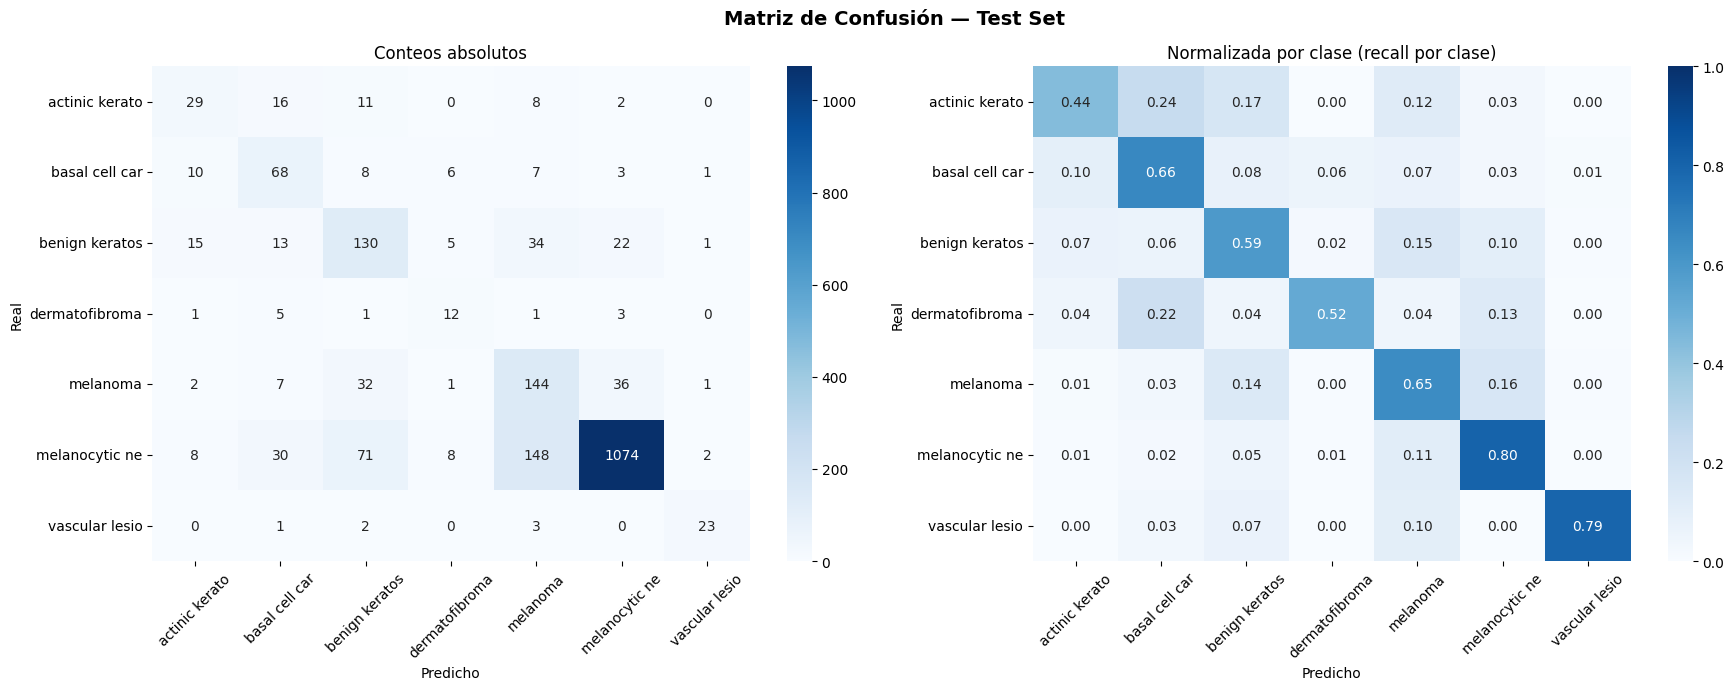

✅ Guardado: confusion_matrix.png

Reporte por clase:
                                                 precision    recall  f1-score   support

actinic keratoses and intraepithelial carcinoma       0.45      0.44      0.44        66
                           basal cell carcinoma       0.49      0.66      0.56       103
                  benign keratosis-like lesions       0.51      0.59      0.55       220
                                 dermatofibroma       0.38      0.52      0.44        23
                                       melanoma       0.42      0.65      0.51       223
                               melanocytic nevi       0.94      0.80      0.87      1341
                               vascular lesions       0.82      0.79      0.81        29

                                       accuracy                           0.74      2005
                                      macro avg       0.57      0.64      0.60      2005
                                   weighted avg       0

In [7]:
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizada por fila

short_names = [n[:14] for n in CLASS_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matriz de Confusión — Test Set', fontsize=14, fontweight='bold')

# Absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names, ax=axes[0])
axes[0].set_title('Conteos absolutos')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Normalizada por clase (recall por clase)')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: confusion_matrix.png')

# Métricas por clase
from sklearn.metrics import classification_report
print('\nReporte por clase:')
print(classification_report(test_labels, test_preds,
      target_names=CLASS_NAMES, zero_division=0))

## 11. Guardar artefactos para Fase 4

In [8]:
import pickle

# Guardar resultados del test para usar en Fase 4 (Grad-CAM)
artefactos = {
    'test_preds' : test_preds,
    'test_labels': test_labels,
    'test_probs' : test_probs,
    #'history'    : history,
    'test_acc'   : test_acc,
    'test_f1'    : test_f1,
    'test_auc'   : test_auc,
}

with open('test_results.pkl', 'wb') as f:
    pickle.dump(artefactos, f)

print('Archivos listos para Fase 4:')
print('  best_model.pth    — pesos del mejor modelo')
print('  test_results.pkl  — métricas y predicciones del test set')
print('  curvas_entrenamiento.png — para el reporte IEEE')
print('  confusion_matrix.png    — para el reporte IEEE')
print()
print('✅ Fase 3 completa — listo para Fase 4: Grad-CAM')

Archivos listos para Fase 4:
  best_model.pth    — pesos del mejor modelo
  test_results.pkl  — métricas y predicciones del test set
  curvas_entrenamiento.png — para el reporte IEEE
  confusion_matrix.png    — para el reporte IEEE

✅ Fase 3 completa — listo para Fase 4: Grad-CAM


## ✅ Resumen Fase 3

| Decisión | Justificación |
|----------|---------------|
| `AdamW` | Mejor regularización que Adam estándar (weight decay separado) |
| `CosineAnnealingLR` | Evita mínimos locales — baja LR suavemente |
| `CrossEntropyLoss(weight=...)` | Segunda línea de defensa contra desbalance |
| Gradient clipping (norm=1.0) | Evita explosión de gradientes en las fusiones no lineales |
| Early stopping en F1-Macro | Métrica más representativa para datasets desbalanceados |
| Checkpoint del mejor modelo | Evita sobreajuste al final del entrenamiento |

**Siguiente paso → Fase 4: Evaluación + Grad-CAM (XAI)**